In [1]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import math

import xgboost as xgb
from ngboost import NGBRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
import optuna

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")

In [2]:
X_train_raw = pd.read_csv('../../data/processed/X_train_v2.csv')
y_train_raw = pd.read_csv('../../data/processed/y_train_v2.csv')

X_test_raw = pd.read_csv('../../data/processed/X_test_v2.csv')
y_test_raw = pd.read_csv('../../data/processed/y_test_v2.csv')

print(f"X_train boyutu: {X_train_raw.shape}")
print(f"y_train boyutu: {y_train_raw.shape}")
print(f"X_test boyutu:  {X_test_raw.shape}")
print(f"y_test boyutu:  {y_test_raw.shape}")

display(X_train_raw.head(3))

X_train boyutu: (413, 22)
y_train boyutu: (413, 1)
X_test boyutu:  (104, 22)
y_test boyutu:  (104, 1)


,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,...,day_sin,day_cos,is_weekend,is_peak_season,distance_to_center,dynamic_seasonal_hotspot_distance,moderate_wind_danger,hot_and_dry,double_drought,ISI_x_DC
0,2,5,93.9,135.7,586.7,15.1,23.5,36,5.4,0,...,-0.974928,-0.222521,0,1,3.000000,6.082763,1,1,1,8859.17
1,8,6,91.7,33.3,77.5,9.0,8.3,97,4.0,1,...,-0.974928,-0.222521,0,1,3.162278,2.236068,1,0,0,697.50
2,4,3,91.9,111.7,770.3,6.5,15.9,53,2.2,0,...,0.974928,-0.222521,0,1,2.236068,5.000000,0,0,1,5006.95


In [3]:
def calculate_bui(dmc, dc):

    dmc = np.array(dmc, dtype=float)
    dc = np.array(dc, dtype=float)
    bui = np.zeros_like(dmc)
    
    eps = 1e-6
    mask = dmc <= 0.4 * dc
    
    bui[mask] = (0.8 * dmc[mask] * dc[mask]) / (dmc[mask] + 0.4 * dc[mask] + eps)
    
    bui[~mask] = dmc[~mask] - (1 - (0.8 * dc[~mask]) / (dmc[~mask] + 0.4 * dc[~mask] + eps)) * (0.92 + (0.0114 * dmc[~mask])**1.7)
    
    return np.maximum(0, bui) # Endeksler negatif olamaz

def calculate_fwi(isi, bui):

    isi = np.array(isi, dtype=float)
    bui = np.array(bui, dtype=float)
    f_d = np.zeros_like(bui)
    
    mask_bui = bui <= 80
    f_d[mask_bui] = 0.626 * (bui[mask_bui]**0.809) + 2
    f_d[~mask_bui] = 1000 / (25 + 108.64 * np.exp(-0.023 * bui[~mask_bui]))
    
    B = 0.1 * isi * f_d
    fwi = np.zeros_like(B)
    
    mask_B = B > 1
    fwi[mask_B] = np.exp(2.72 * (0.434 * np.log(B[mask_B] + 1e-6))**0.647)
    fwi[~mask_B] = B[~mask_B]
    
    return np.maximum(0, fwi)

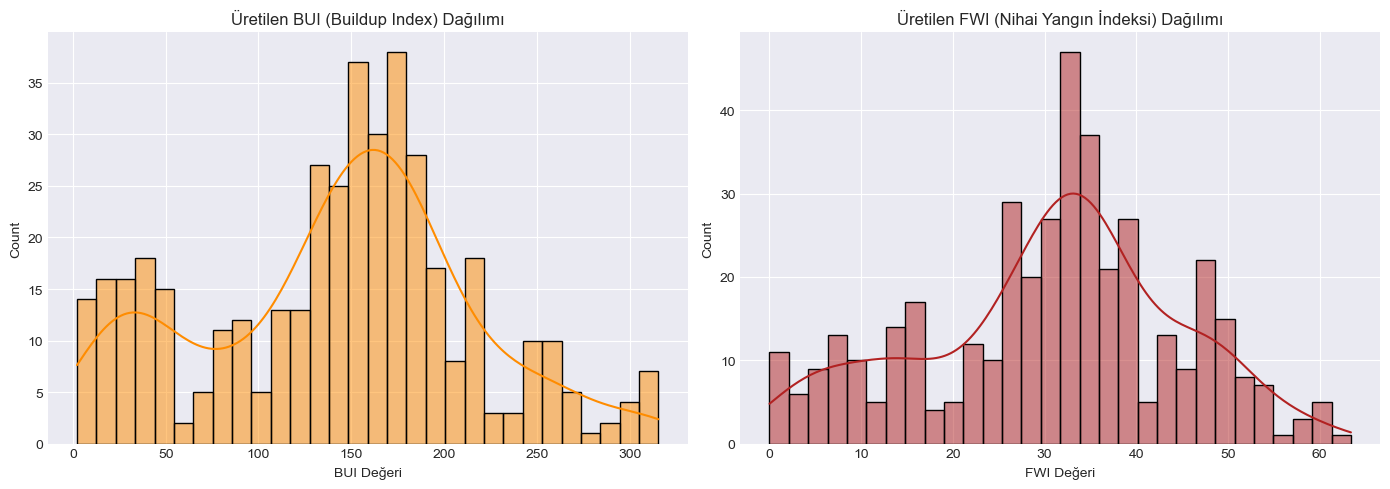

,DMC,DC,ISI,BUI,FWI
0,135.7,586.7,15.1,171.964339,49.387596
1,33.3,77.5,9.0,33.260199,16.736805
2,111.7,770.3,6.5,163.960764,28.179714


In [4]:
X_train_temp = X_train_raw.copy()
X_test_temp = X_test_raw.copy()

X_train_temp['BUI'] = calculate_bui(X_train_temp['DMC'], X_train_temp['DC'])
X_train_temp['FWI'] = calculate_fwi(X_train_temp['ISI'], X_train_temp['BUI'])

X_test_temp['BUI'] = calculate_bui(X_test_temp['DMC'], X_test_temp['DC'])
X_test_temp['FWI'] = calculate_fwi(X_test_temp['ISI'], X_test_temp['BUI'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(X_train_temp['BUI'], kde=True, ax=axes[0], color='darkorange', bins=30)
axes[0].set_title('Üretilen BUI (Buildup Index) Dağılımı', fontsize=12)
axes[0].set_xlabel('BUI Değeri')

sns.histplot(X_train_temp['FWI'], kde=True, ax=axes[1], color='firebrick', bins=30)
axes[1].set_title('Üretilen FWI (Nihai Yangın İndeksi) Dağılımı', fontsize=12)
axes[1].set_xlabel('FWI Değeri')

plt.tight_layout()
plt.show()

display(X_train_temp[['DMC', 'DC', 'ISI', 'BUI', 'FWI']].head(3))

In [5]:
print("--- HEDEF DEĞİŞKEN (Y) ÖLÇEK KONTROLÜ ---")
y_train_max = y_train_raw.iloc[:, 0].max()
y_test_max = y_test_raw.iloc[:, 0].max()

print(f"y_train_raw Maksimum Değer: {y_train_max:.2f}")
print(f"y_test_raw Maksimum Değer:  {y_test_max:.2f}")

y_train_temp = y_train_raw.copy()
y_test_temp = y_test_raw.copy()

def fix_scale(df, name):
    max_val = df.iloc[:, 0].max()
    if max_val < 10:
        print(f"⚠️ {name} Log1p formatında tespit edildi! Raw'a çevriliyor (expm1)...")
        df.iloc[:, 0] = np.expm1(df.iloc[:, 0])
        
    elif 10 < max_val < 50:
        print(f"⚠️ {name} Tweedie formatında tespit edildi! Raw'a çevriliyor (Ters Dönüşüm)...")
        df.iloc[:, 0] = (df.iloc[:, 0] / 4.0) ** 4
        
    else:
        print(f"✅ {name} zaten RAW (Ham Hektar) formatında. İşleme gerek yok.")
        
    return df

y_train_temp = fix_scale(y_train_temp, "y_train")
y_test_temp = fix_scale(y_test_temp, "y_test")

print("\n--- DÜZELTME SONRASI SON DURUM (TEMİZ VERİ) ---")
print(f"y_train_temp Yeni Max: {y_train_temp.iloc[:, 0].max():.2f} Hektar")
print(f"y_test_temp Yeni Max:  {y_test_temp.iloc[:, 0].max():.2f} Hektar")

--- HEDEF DEĞİŞKEN (Y) ÖLÇEK KONTROLÜ ---
y_train_raw Maksimum Değer: 20.91
y_test_raw Maksimum Değer:  1090.84
⚠️ y_train Tweedie formatında tespit edildi! Raw'a çevriliyor (Ters Dönüşüm)...
✅ y_test zaten RAW (Ham Hektar) formatında. İşleme gerek yok.

--- DÜZELTME SONRASI SON DURUM (TEMİZ VERİ) ---
y_train_temp Yeni Max: 746.28 Hektar
y_test_temp Yeni Max:  1090.84 Hektar


In [8]:
from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split
from sklearn.metrics import median_absolute_error
from sklearn.linear_model import ARDRegression

X_opt_train, X_opt_val, y_opt_train, y_opt_val = train_test_split(
    X_train_temp, y_train_temp.iloc[:, 0], test_size=0.2, random_state=42
)

zeros_mask_val = (y_opt_val == 0)

def objective(trial):
    p = trial.suggest_float("p", 1.1, 1.9)
    k = 1.0 - (p / 2.0)
    
    y_opt_train_trans = y_opt_train ** k
    
    models = {
        "XGBoost": xgb.XGBRegressor(n_estimators=100, max_depth=4, random_state=42, n_jobs=-1),
        "RandomForest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1),
        "SVR": SVR(C=1.0, kernel='rbf'),
        "NGBoost": NGBRegressor(n_estimators=100, random_state=42, verbose=False),
        "RVM_ARD": ARDRegression()
    }
    
    total_composite_loss = 0
    
    for name, model in models.items():
        model.fit(X_opt_train, y_opt_train_trans)
        pred_trans = model.predict(X_opt_val)
        
        pred_trans = np.maximum(0, pred_trans) 
        pred_raw = pred_trans ** (1.0 / k)
        
        medae = median_absolute_error(y_opt_val, pred_raw)
        zero_fp_error = np.mean(pred_raw[zeros_mask_val]) if zeros_mask_val.sum() > 0 else 0
        spearman_corr, _ = spearmanr(y_opt_val, pred_raw)
        if np.isnan(spearman_corr):
            spearman_corr = 0
            
        custom_loss = medae + zero_fp_error - (spearman_corr * 10)
        total_composite_loss += custom_loss
        
    return total_composite_loss / len(models)

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

best_p = study.best_params['p']
best_k = 1.0 - (best_p / 2.0)

print(f"Best p: {best_p:.4f} | lambda (k): {best_k:.4f}\n")
print("-" * 50)

y_opt_train_trans = y_opt_train ** best_k

final_models = {
    "XGBoost": xgb.XGBRegressor(n_estimators=100, max_depth=4, random_state=42, n_jobs=-1),
    "RandomForest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1),
    "SVR": SVR(C=1.0, kernel='rbf'),
    "NGBoost": NGBRegressor(n_estimators=100, random_state=42, verbose=False),
    "RVM_ARD": ARDRegression()
}

for name, model in final_models.items():
    model.fit(X_opt_train, y_opt_train_trans)
    pred_trans = model.predict(X_opt_val)
    
    pred_trans = np.maximum(0, pred_trans) 
    pred_raw = pred_trans ** (1.0 / best_k)
    
    medae = median_absolute_error(y_opt_val, pred_raw)
    zero_fp_error = np.mean(pred_raw[zeros_mask_val]) if zeros_mask_val.sum() > 0 else 0
    spearman_corr, _ = spearmanr(y_opt_val, pred_raw)
    if np.isnan(spearman_corr):
        spearman_corr = 0
        
    custom_loss = medae + zero_fp_error - (spearman_corr * 10)
    
    print(f"Model: {name}")
    print(f"  MedAE:    {medae:.4f}")
    print(f"  Zero_FP:  {zero_fp_error:.4f}")
    print(f"  Spearman: {spearman_corr:.4f}")
    print(f"  Loss:     {custom_loss:.4f}\n")

Best p: 1.8043 | lambda (k): 0.0978

--------------------------------------------------
Model: XGBoost
  MedAE:    2.2436
  Zero_FP:  2.8990
  Spearman: -0.0653
  Loss:     5.7954

Model: RandomForest
  MedAE:    1.9368
  Zero_FP:  0.0621
  Spearman: -0.0635
  Loss:     2.6344

Model: SVR
  MedAE:    1.6332
  Zero_FP:  0.2595
  Spearman: -0.2227
  Loss:     4.1198

Model: NGBoost
  MedAE:    1.9329
  Zero_FP:  0.0554
  Spearman: -0.0368
  Loss:     2.3565

Model: RVM_ARD
  MedAE:    1.9414
  Zero_FP:  0.0091
  Spearman: -0.1353
  Loss:     3.3036



In [10]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

def iterative_vif_selection_domain_aware(df, threshold=10.0):
    X = df.astype(float).copy()
    
    manual_drops = ['DMC', 'DC']
    existing_drops = [col for col in manual_drops if col in X.columns]
    X = X.drop(columns=existing_drops)
    
    dropped_features = existing_drops.copy()
    
    while True:
        X_vif = X.copy()
        X_vif['Intercept'] = 1.0
        
        vif_data = pd.DataFrame()
        vif_data["Feature"] = X_vif.columns
        vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
        
        vif_data = vif_data[vif_data["Feature"] != 'Intercept']
        max_vif = vif_data["VIF"].max()
        
        if max_vif > threshold:
            feature_to_drop = vif_data.loc[vif_data["VIF"].idxmax(), "Feature"]
            dropped_features.append(feature_to_drop)
            X = X.drop(columns=[feature_to_drop])
        else:
            break
            
    return X, dropped_features, vif_data.sort_values(by="VIF", ascending=False)

X_train_vif_filtered, dropped, final_vif_table = iterative_vif_selection_domain_aware(X_train_temp, threshold=10.0)

print(f"Dropped Features: {dropped}\n")
print("-" * 40)
print("Final VIF Table:")
display(final_vif_table)

Dropped Features: ['DMC', 'DC', 'FWI', 'ISI_x_DC', 'dynamic_seasonal_hotspot_distance']

----------------------------------------
Final VIF Table:


,Feature,VIF
4,temp,4.879737
17,double_drought,4.474109
8,month_sin,4.069567
18,BUI,3.777702
12,is_weekend,3.253198
11,day_cos,3.066799
5,RH,2.927252
9,month_cos,2.227331
16,hot_and_dry,2.104385
2,FFMC,2.005124


In [11]:
X_opt_train_vif, X_opt_val_vif, y_opt_train_vif, y_opt_val_vif = train_test_split(
    X_train_vif_filtered, y_train_temp.iloc[:, 0], test_size=0.2, random_state=42
)

zeros_mask_val_vif = (y_opt_val_vif == 0)

def objective_vif(trial):
    p = trial.suggest_float("p", 1.1, 1.9)
    k = 1.0 - (p / 2.0)
    
    y_opt_train_trans = y_opt_train_vif ** k
    
    models = {
        "XGBoost": xgb.XGBRegressor(n_estimators=100, max_depth=4, random_state=42, n_jobs=-1),
        "RandomForest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1),
        "SVR": SVR(C=1.0, kernel='rbf'),
        "NGBoost": NGBRegressor(n_estimators=100, random_state=42, verbose=False),
        "RVM_ARD": ARDRegression()
    }
    
    total_composite_loss = 0
    
    for name, model in models.items():
        if name == "NGBoost":
            model.fit(X_opt_train_vif, y_opt_train_trans)
        else:
            model.fit(X_opt_train_vif, y_opt_train_trans)
            
        pred_trans = model.predict(X_opt_val_vif)
        
        pred_trans = np.maximum(0, pred_trans) 
        pred_raw = pred_trans ** (1.0 / k)
        
        medae = median_absolute_error(y_opt_val_vif, pred_raw)
        zero_fp_error = np.mean(pred_raw[zeros_mask_val_vif]) if zeros_mask_val_vif.sum() > 0 else 0
        spearman_corr, _ = spearmanr(y_opt_val_vif, pred_raw)
        if np.isnan(spearman_corr):
            spearman_corr = 0
            
        custom_loss = medae + zero_fp_error - (spearman_corr * 10)
        total_composite_loss += custom_loss
        
    return total_composite_loss / len(models)

optuna.logging.set_verbosity(optuna.logging.WARNING)
study_vif = optuna.create_study(direction="minimize")
study_vif.optimize(objective_vif, n_trials=50)

best_p_vif = study_vif.best_params['p']
best_k_vif = 1.0 - (best_p_vif / 2.0)

print(f"VIF Sonrası Best p: {best_p_vif:.4f} | lambda (k): {best_k_vif:.4f}\n")
print("-" * 50)

y_opt_train_trans_vif = y_opt_train_vif ** best_k_vif

final_models_vif = {
    "XGBoost": xgb.XGBRegressor(n_estimators=100, max_depth=4, random_state=42, n_jobs=-1),
    "RandomForest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1),
    "SVR": SVR(C=1.0, kernel='rbf'),
    "NGBoost": NGBRegressor(n_estimators=100, random_state=42, verbose=False),
    "RVM_ARD": ARDRegression()
}

for name, model in final_models_vif.items():
    model.fit(X_opt_train_vif, y_opt_train_trans_vif)
    pred_trans = model.predict(X_opt_val_vif)
    
    pred_trans = np.maximum(0, pred_trans) 
    pred_raw = pred_trans ** (1.0 / best_k_vif)
    
    medae = median_absolute_error(y_opt_val_vif, pred_raw)
    zero_fp_error = np.mean(pred_raw[zeros_mask_val_vif]) if zeros_mask_val_vif.sum() > 0 else 0
    spearman_corr, _ = spearmanr(y_opt_val_vif, pred_raw)
    if np.isnan(spearman_corr):
        spearman_corr = 0
        
    custom_loss = medae + zero_fp_error - (spearman_corr * 10)
    
    print(f"Model: {name}")
    print(f"  MedAE:    {medae:.4f}")
    print(f"  Zero_FP:  {zero_fp_error:.4f}")
    print(f"  Spearman: {spearman_corr:.4f}")
    print(f"  Loss:     {custom_loss:.4f}\n")

VIF Sonrası Best p: 1.6862 | lambda (k): 0.1569

--------------------------------------------------
Model: XGBoost
  MedAE:    4.2420
  Zero_FP:  4.9607
  Spearman: -0.1803
  Loss:     11.0056

Model: RandomForest
  MedAE:    2.1007
  Zero_FP:  0.3822
  Spearman: -0.0613
  Loss:     3.0963

Model: SVR
  MedAE:    1.6502
  Zero_FP:  0.2602
  Spearman: -0.0441
  Loss:     2.3516

Model: NGBoost
  MedAE:    2.0768
  Zero_FP:  0.3631
  Spearman: -0.1170
  Loss:     3.6098

Model: RVM_ARD
  MedAE:    1.8477
  Zero_FP:  0.1055
  Spearman: -0.1361
  Loss:     3.3144



In [12]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.metrics import median_absolute_error

def calculate_custom_loss(y_true, pred_raw):
    medae = median_absolute_error(y_true, pred_raw)
    zeros_mask = (y_true == 0)
    zero_fp = np.mean(pred_raw[zeros_mask]) if zeros_mask.sum() > 0 else 0
    scorr, _ = spearmanr(y_true, pred_raw)
    if np.isnan(scorr): 
        scorr = 0
    return medae + zero_fp - (scorr * 10)

feature_importances = {col: 0.0 for col in X_opt_val_vif.columns}

for name, model in final_models_vif.items():
    pred_trans_base = np.maximum(0, model.predict(X_opt_val_vif))
    pred_raw_base = pred_trans_base ** (1.0 / best_k_vif)
    base_loss = calculate_custom_loss(y_opt_val_vif.values, pred_raw_base)
    
    for col in X_opt_val_vif.columns:
        X_shuffled = X_opt_val_vif.copy()
        
        # Özelliği bozuyoruz
        X_shuffled[col] = np.random.permutation(X_shuffled[col].values)
        
        pred_trans_shuf = np.maximum(0, model.predict(X_shuffled))
        pred_raw_shuf = pred_trans_shuf ** (1.0 / best_k_vif)
        shuf_loss = calculate_custom_loss(y_opt_val_vif.values, pred_raw_shuf)
        
        # Importance = Bozulan Hata - Orijinal Hata
        importance = shuf_loss - base_loss
        feature_importances[col] += importance

for col in feature_importances:
    feature_importances[col] /= len(final_models_vif)

importance_df = pd.DataFrame(list(feature_importances.items()), columns=['Feature', 'Importance Score'])
importance_df = importance_df.sort_values(by='Importance Score', ascending=False)

print("Feature Permutation Importance (Consensus of 5 Models):\n")
print("[+] Pozitif Skor: Faydalı Özellik")
print("[-] Negatif Skor: Modele Zarar Veren Özellik (Silinmeli)\n")
display(importance_df)

Feature Permutation Importance (Consensus of 5 Models):

[+] Pozitif Skor: Faydalı Özellik
[-] Negatif Skor: Modele Zarar Veren Özellik (Silinmeli)



,Feature,Importance Score
5,RH,4.617550e-01
0,X,2.938888e-01
9,month_cos,1.583868e-01
15,moderate_wind_danger,9.016951e-02
7,rain,8.881784e-17
4,temp,-4.552559e-03
17,double_drought,-5.832988e-03
13,is_peak_season,-1.887192e-02
16,hot_and_dry,-1.905996e-02
12,is_weekend,-4.098405e-02


In [13]:
core_features = ['temp', 'RH', 'wind', 'rain', 'BUI', 'ISI', 'FFMC']

X_opt_train_pure = X_opt_train_vif[core_features]
X_opt_val_pure = X_opt_val_vif[core_features]

def objective_pure(trial):
    p = trial.suggest_float("p", 1.1, 1.9)
    k = 1.0 - (p / 2.0)
    
    y_opt_train_trans = y_opt_train_vif ** k
    
    models = {
        "XGBoost": xgb.XGBRegressor(n_estimators=100, max_depth=3, random_state=42, n_jobs=-1),
        "RandomForest": RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42, n_jobs=-1),
        "SVR": SVR(C=1.0, kernel='rbf'),
        "NGBoost": NGBRegressor(n_estimators=100, random_state=42, verbose=False),
        "RVM_ARD": ARDRegression()
    }
    
    total_composite_loss = 0
    
    for name, model in models.items():
        if name == "NGBoost":
            model.fit(X_opt_train_pure, y_opt_train_trans)
        else:
            model.fit(X_opt_train_pure, y_opt_train_trans)
            
        pred_trans = model.predict(X_opt_val_pure)
        pred_trans = np.maximum(0, pred_trans) 
        pred_raw = pred_trans ** (1.0 / k)
        
        medae = median_absolute_error(y_opt_val_vif, pred_raw)
        zero_fp_error = np.mean(pred_raw[zeros_mask_val_vif]) if zeros_mask_val_vif.sum() > 0 else 0
        spearman_corr, _ = spearmanr(y_opt_val_vif, pred_raw)
        if np.isnan(spearman_corr):
            spearman_corr = 0
            
        custom_loss = medae + zero_fp_error - (spearman_corr * 10)
        total_composite_loss += custom_loss
        
    return total_composite_loss / len(models)

optuna.logging.set_verbosity(optuna.logging.WARNING)
study_pure = optuna.create_study(direction="minimize")
study_pure.optimize(objective_pure, n_trials=50)

best_p_pure = study_pure.best_params['p']
best_k_pure = 1.0 - (best_p_pure / 2.0)

print(f"Saf Fiziksel Veri Best p: {best_p_pure:.4f} | lambda (k): {best_k_pure:.4f}\n")
print("-" * 50)

y_opt_train_trans_pure = y_opt_train_vif ** best_k_pure

for name, model in final_models_vif.items():
    model.fit(X_opt_train_pure, y_opt_train_trans_pure)
    pred_trans = model.predict(X_opt_val_pure)
    
    pred_trans = np.maximum(0, pred_trans) 
    pred_raw = pred_trans ** (1.0 / best_k_pure)
    
    medae = median_absolute_error(y_opt_val_vif, pred_raw)
    zero_fp_error = np.mean(pred_raw[zeros_mask_val_vif]) if zeros_mask_val_vif.sum() > 0 else 0
    spearman_corr, _ = spearmanr(y_opt_val_vif, pred_raw)
    if np.isnan(spearman_corr):
        spearman_corr = 0
        
    custom_loss = medae + zero_fp_error - (spearman_corr * 10)
    
    print(f"Model: {name}")
    print(f"  MedAE:    {medae:.4f}")
    print(f"  Zero_FP:  {zero_fp_error:.4f}")
    print(f"  Spearman: {spearman_corr:.4f}")
    print(f"  Loss:     {custom_loss:.4f}\n")

Saf Fiziksel Veri Best p: 1.7837 | lambda (k): 0.1082

--------------------------------------------------
Model: XGBoost
  MedAE:    2.7929
  Zero_FP:  4.5607
  Spearman: 0.0826
  Loss:     6.5271

Model: RandomForest
  MedAE:    1.8490
  Zero_FP:  0.1230
  Spearman: 0.0326
  Loss:     1.6459

Model: SVR
  MedAE:    1.5310
  Zero_FP:  0.2661
  Spearman: -0.0218
  Loss:     2.0150

Model: NGBoost
  MedAE:    1.9026
  Zero_FP:  0.0847
  Spearman: -0.0090
  Loss:     2.0773

Model: RVM_ARD
  MedAE:    1.8976
  Zero_FP:  0.0146
  Spearman: -0.0692
  Loss:     2.6043



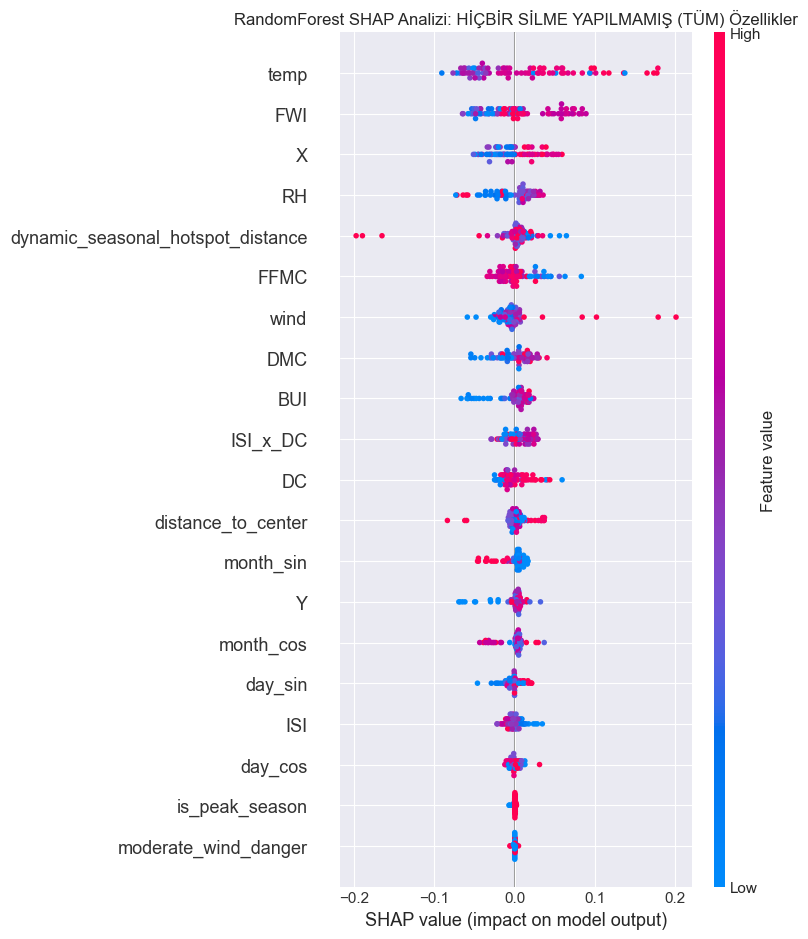

In [17]:
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

X_shap_all, X_val_shap_all, y_shap_train_all, y_shap_val_all = train_test_split(
    X_train_temp, y_train_temp.iloc[:, 0], test_size=0.2, random_state=42
)

y_shap_trans_all = y_shap_train_all ** best_k_pure

rf_model_all = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)
rf_model_all.fit(X_shap_all, y_shap_trans_all)

explainer_all = shap.TreeExplainer(rf_model_all)
shap_values_all = explainer_all(X_val_shap_all)

plt.figure(figsize=(10, 10)) 
plt.title("RandomForest SHAP Analizi: HİÇBİR SİLME YAPILMAMIŞ (TÜM) Özellikler")
shap.summary_plot(shap_values_all, X_val_shap_all, show=False)
plt.tight_layout()
plt.show()

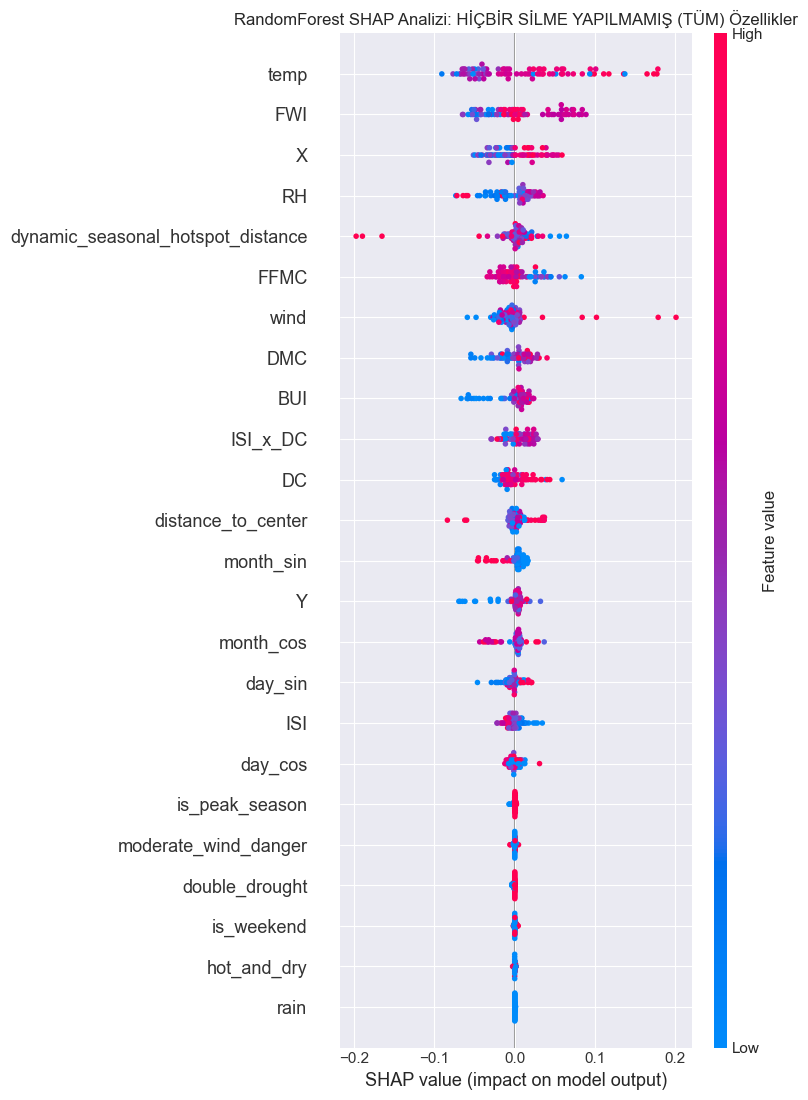

In [18]:
plt.figure(figsize=(10, 12)) 
plt.title("RandomForest SHAP Analizi: HİÇBİR SİLME YAPILMAMIŞ (TÜM) Özellikler")
shap.summary_plot(shap_values_all, X_val_shap_all, max_display=50, show=False)

plt.tight_layout()
plt.show()

In [19]:
import pandas as pd

rain_analysis_df = X_train_temp[['rain']].copy()
rain_analysis_df['Yanan_Alan (Hektar)'] = y_train_temp.iloc[:, 0]

rainy_days = rain_analysis_df[rain_analysis_df['rain'] > 0.0]

rainy_days = rainy_days.sort_values(by='rain', ascending=False)

print(f"Toplam Gün Sayısı: {len(X_train_temp)}")
print(f"Yağmur Yağan Gün Sayısı: {len(rainy_days)}\n")
print("Yağmurlu Günlerdeki Yanan Alanlar (Hektar):")
display(rainy_days)

Toplam Gün Sayısı: 413
Yağmur Yağan Gün Sayısı: 7

Yağmurlu Günlerdeki Yanan Alanlar (Hektar):


,rain,Yanan_Alan (Hektar)
1,1,0.00
190,1,0.00
301,1,0.00
340,1,0.00
352,1,10.82
384,1,2.17
404,1,0.00


In [20]:
rainy_days_full = X_train_temp[X_train_temp['rain'] > 0].copy()

rainy_days_full['Yanan_Alan'] = y_train_temp.loc[rainy_days_full.index, y_train_temp.columns[0]]

cols_to_view = ['rain', 'temp', 'wind', 'RH', 'BUI', 'ISI', 'FWI', 'Yanan_Alan']

print("Yağmur Yağan 7 Günün Fiziksel Anatomisi:")
display(rainy_days_full[cols_to_view].sort_values(by='Yanan_Alan', ascending=False))

Yağmur Yağan 7 Günün Fiziksel Anatomisi:


,rain,temp,wind,RH,BUI,ISI,FWI,Yanan_Alan
352,1,27.3,4.9,63,216.298447,14.3,49.261867,10.82
384,1,21.1,7.6,71,214.743668,7.1,31.256789,2.17
1,1,8.3,4.0,97,33.260199,9.0,16.736805,0.00
301,1,20.7,4.9,69,216.298447,14.3,49.261867,0.00
190,1,12.6,7.6,90,183.001169,12.5,44.309746,0.00
340,1,21.9,7.6,73,215.543185,13.8,48.156358,0.00
404,1,21.6,4.9,65,216.298447,14.3,49.261867,0.00


In [21]:
import numpy as np

def rain_gating_layer(predictions, df_features):
    """
    Yağmurlu günlerde tahmin edilen yanan alanı, o günkü sıcaklığa (temp) göre
    dinamik olarak ölçeklendiren (baskılayan) Kural Tabanlı Katman (Heuristic Override).
    
    predictions: Modelin ürettiği ham tahmin dizisi (numpy array)
    df_features: Tahminin yapıldığı günlerin özelliklerini içeren DataFrame
    """
    final_predictions = np.array(predictions).copy()
    
    temp_values = df_features['temp'].values
    rain_values = df_features['rain'].values
    
    rainy_indices = np.where(rain_values > 0)[0]
    
    if len(rainy_indices) > 0:
        temp_rainy = temp_values[rainy_indices]
        multipliers = np.clip((temp_rainy - 15.0) / 12.0, 0.0, 1.0)
        final_predictions[rainy_indices] = final_predictions[rainy_indices] * multipliers
        
    return final_predictions


In [23]:
import pandas as pd

try:
    X_all = pd.concat([X_train_temp, X_test_temp])
    y_all = pd.concat([y_train_temp, y_test_temp]).iloc[:, 0]
except NameError:
    print("HATA: X_test_temp değişkeni bulunamadı. Lütfen test setinizin doğru ismini koda yazın.")

mega_analysis_all_df = X_all.copy()
mega_analysis_all_df['Yanan_Alan'] = y_all

mega_fires_all = mega_analysis_all_df[mega_analysis_all_df['Yanan_Alan'] > 105.66].sort_values(by='Yanan_Alan', ascending=False)

cols_to_compare = ['temp', 'wind', 'RH', 'BUI', 'ISI', 'FWI']

print(f"TÜM TARİHSEL VERİDEKİ (Train+Test) Mega Yangın Günü Sayısı: {len(mega_fires_all)}")
print("\nTarihteki Tüm Devasa Yangınların Anatomisi:")
display(mega_fires_all[cols_to_compare + ['Yanan_Alan']])

TÜM TARİHSEL VERİDEKİ (Train+Test) Mega Yangın Günü Sayısı: 10

Tarihteki Tüm Devasa Yangınların Anatomisi:


,temp,wind,RH,BUI,ISI,FWI,Yanan_Alan
86,25.1,4.0,27,167.159269,8.6,34.165759,1090.84
67,27.5,4.9,27,247.678367,13.9,48.852965,746.28
298,22.6,4.9,57,129.726592,6.4,25.967381,278.53
195,18.8,2.2,40,176.497663,7.0,30.102379,212.88
165,18.2,1.8,46,167.159269,8.6,34.165759,200.94
28,19.6,5.8,41,178.899853,10.6,39.704393,196.48
187,26.2,4.5,36,218.433704,7.8,33.338640,185.76
129,21.9,2.2,42,255.651637,8.4,35.390034,174.63
41,17.7,3.1,25,167.159269,8.6,34.165759,154.88
242,24.3,3.1,36,115.308534,3.2,14.927396,105.66


In [26]:
import pandas as pd

try:
    X_all = pd.concat([X_train_temp, X_test_temp], ignore_index=True)
    y_all = pd.concat([y_train_temp, y_test_temp], ignore_index=True)
except NameError:
    print("HATA: X_test_temp bulunamadı, test setinizin adını koda yazınız.")

X_all['Yanan_Alan'] = y_all.iloc[:, 0]

# 3. Kıyamet Günü Şartları (En Büyük 2 Mega Yangının Ortak Özellikleri)
# temp > 25, RH <= 30, BUI > 160
doomsday_conditions = X_all[(X_all['temp'] > 25) & (X_all['RH'] <= 30) & (X_all['BUI'] > 160)].copy()

print(f"Kıyamet Şartlarının (temp>25, RH<=30, BUI>160) Tarihte Görüldüğü Toplam Gün Sayısı: {len(doomsday_conditions)}")
print("Bu Şartlardaki Günlerin Sonuçları:")

cols_to_show = ['temp', 'RH', 'BUI', 'wind', 'FWI', 'Yanan_Alan']
display(doomsday_conditions[cols_to_show].sort_values(by='Yanan_Alan', ascending=False))

Kıyamet Şartlarının (temp>25, RH<=30, BUI>160) Tarihte Görüldüğü Toplam Gün Sayısı: 33
Bu Şartlardaki Günlerin Sonuçları:


,temp,RH,BUI,wind,FWI,Yanan_Alan
499,25.1,27,167.159269,4.0,34.165759,1090.84
67,27.5,27,247.678367,4.9,48.852965,746.28
436,27.8,27,197.449707,3.1,33.798987,95.18
219,26.4,21,180.581265,4.5,36.261628,88.49
283,26.9,28,180.300884,5.4,40.721692,86.45
289,28.3,26,197.449707,3.1,33.798987,64.10
459,28.9,29,185.159097,4.9,59.523642,49.59
402,27.5,29,194.650593,4.5,41.922520,43.32
418,33.3,26,216.298447,2.7,49.261867,40.54
330,33.1,25,167.605039,4.0,47.062519,26.43


In [28]:
doomsday_all_features = X_all.loc[doomsday_conditions.index].copy()
doomsday_all_features['Yanan_Alan'] = y_all.loc[doomsday_conditions.index]

doomsday_all_features['Kiyamet_Koptu_Mu'] = doomsday_all_features['Yanan_Alan'] > 700

other_cols = ['X', 'Y', 'distance_to_center', 'dynamic_seasonal_hotspot_distance', 
              'month_sin', 'month_cos', 'day_sin', 'day_cos', 'FFMC', 'DMC', 'DC', 'ISI_x_DC']

print("--- 700+ Hektarlık 2 Gün İle, Ucuz Atlatılan 31 Günün GİZLİ ÖZELLİKLER Karşılaştırması ---")
print(doomsday_all_features.groupby('Kiyamet_Koptu_Mu')[other_cols].mean().T.to_string())

print("\n--- Kıyametin Koptuğu O 2 Günün BİREBİR Tüm Detayları ---")
print(doomsday_all_features[doomsday_all_features['Kiyamet_Koptu_Mu'] == True][other_cols + ['Yanan_Alan']].to_string())

--- 700+ Hektarlık 2 Gün İle, Ucuz Atlatılan 31 Günün GİZLİ ÖZELLİKLER Karşılaştırması ---
Kiyamet_Koptu_Mu                         False        True 
X                                     4.322581     7.000000
Y                                     4.483871     5.500000
distance_to_center                    2.660794     2.081139
dynamic_seasonal_hotspot_distance     4.077415     1.118034
month_sin                            -0.885628    -0.933013
month_cos                            -0.362324    -0.250000
day_sin                               0.062214    -0.607858
day_cos                              -0.096930    -0.138740
FFMC                                 94.141935    93.650000
DMC                                 161.467742   171.750000
DC                                  667.964516   686.500000
ISI_x_DC                           8190.923548  7755.190000

--- Kıyametin Koptuğu O 2 Günün BİREBİR Tüm Detayları ---
     X  Y  distance_to_center  dynamic_seasonal_hotspot_distance  mont

In [29]:
import numpy as np
import pandas as pd

hotspot_analysis = X_all[['dynamic_seasonal_hotspot_distance']].copy()
hotspot_analysis['Yanan_Alan'] = y_all

hotspot_analysis['Uzaklik_Kademesi'] = np.round(hotspot_analysis['dynamic_seasonal_hotspot_distance'])

def zero_count(x):
    return (x == 0).sum()

hotspot_stats = hotspot_analysis.groupby('Uzaklik_Kademesi')['Yanan_Alan'].agg(
    Toplam_Vaka='count',
    Sifir_Yangin_Sayisi=zero_count,
    Ortalama_Alan='mean',
    Maksimum_Alan='max'
).reset_index()

print("--- Sıcak Nokta (Hotspot) Uzaklığına Göre Yangın İstatistikleri ---")
print(hotspot_stats.to_string(index=False))

small_dist_mega_fires = hotspot_analysis[(hotspot_analysis['dynamic_seasonal_hotspot_distance'] <= 2.5) & 
                                         (hotspot_analysis['Yanan_Alan'] > 50)]

print(f"\nUzaklığın 2.5'ten Küçük Olduğu Bölgelerdeki Mega Yangın Sayısı: {len(small_dist_mega_fires)}")
print("Bu Kritik Bölgedeki Mega Yangınların Tüm Listesi:")
print(small_dist_mega_fires.sort_values(by='Yanan_Alan', ascending=False).to_string(index=False))

--- Sıcak Nokta (Hotspot) Uzaklığına Göre Yangın İstatistikleri ---
 Uzaklik_Kademesi  Toplam_Vaka  Sifir_Yangin_Sayisi  Ortalama_Alan  Maksimum_Alan
              0.0           62                   25      21.670323         746.28
              1.0           40                   19       7.933750          86.45
              2.0          118                   55      20.549831        1090.84
              3.0           35                   19       7.487143         103.39
              4.0           84                   43       8.779167         154.88
              5.0           65                   40       3.316000          49.59
              6.0           45                   13       5.390667          54.29
              7.0           40                   16      18.039000         200.94
              8.0           28                   17      13.467143         212.88

Uzaklığın 2.5'ten Küçük Olduğu Bölgelerdeki Mega Yangın Sayısı: 12
Bu Kritik Bölgedeki Mega Yangınların Tüm Lis

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, median_absolute_error

y_gercek = y_all.values # Tüm veri setindeki gerçek yanan alanlar

ortalama_hektar = np.mean(y_gercek)
medyan_hektar = np.median(y_gercek)

print(f"Veri Setinin Aritmetik Ortalaması: {ortalama_hektar:.2f} ha")
print(f"Veri Setinin Medyanı (Ortancası): {medyan_hektar:.2f} ha\n")

# SENARYO 1: Model risk almayıp hep 'Ortalama'yı söylerse (Klasik MSE Mantığı)
mse_tahminler = np.full_like(y_gercek, ortalama_hektar)

# SENARYO 2: Model uyanıklık yapıp hep 'Medyan'ı söylerse (Klasik MAE/SVR Mantığı)
mae_tahminler = np.full_like(y_gercek, medyan_hektar)

print("--- STANDART KAYIP FONKSİYONLARININ ÇÖKÜŞ İSPATI ---")
print("Senaryo 1 (MSE Modeli - Her güne Ortalama Hektar derse):")
print(f" - MAE (Ortalama Hata): {mean_absolute_error(y_gercek, mse_tahminler):.2f}")
print(f" - MedAE (Medyan Hata - False Alarm): {median_absolute_error(y_gercek, mse_tahminler):.2f}")
print("   Sorun: Kötü MedAE! Yangın olmayan yüzlerce güne durduk yere 12 hektar der.\n")

print("Senaryo 2 (MAE Modeli - Her güne Medyan Hektar derse):")
print(f" - MAE (Ortalama Hata): {mean_absolute_error(y_gercek, mae_tahminler):.2f}")
print(f" - MedAE (Medyan Hata): {median_absolute_error(y_gercek, mae_tahminler):.2f}")
print("   Sorun: Under-Prediction! MedAE kusursuzdur (0.52) ama 1090 hektar yandığında da 0.52 der!\n")

print("SONUÇ (ASİMETRİK GEREKSİNİM):")
print("Klasik modellerin bu körlüğünü aşmak için tahmin küçük kaldığında (under-prediction) Gradient/Hessian'ı 5-10 kat artıran ASİMETRİK bir matematik yazmalıyız!")

Veri Setinin Aritmetik Ortalaması: 12.85 ha
Veri Setinin Medyanı (Ortancası): 0.52 ha

--- STANDART KAYIP FONKSİYONLARININ ÇÖKÜŞ İSPATI ---
Senaryo 1 (MSE Modeli - Her güne Ortalama Hektar derse):
 - MAE (Ortalama Hata): 18.57
 - MedAE (Medyan Hata - False Alarm): 12.85
   Sorun: Kötü MedAE! Yangın olmayan yüzlerce güne durduk yere 12 hektar der.

Senaryo 2 (MAE Modeli - Her güne Medyan Hektar derse):
 - MAE (Ortalama Hata): 12.83
 - MedAE (Medyan Hata): 0.52
   Sorun: Under-Prediction! MedAE kusursuzdur (0.52) ama 1090 hektar yandığında da 0.52 der!

SONUÇ (ASİMETRİK GEREKSİNİM):
Klasik modellerin bu körlüğünü aşmak için tahmin küçük kaldığında (under-prediction) Gradient/Hessian'ı 5-10 kat artıran ASİMETRİK bir matematik yazmalıyız!


In [33]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, median_absolute_error, mean_squared_error

# NGBoost kontrolü
try:
    from ngboost import NGBRegressor
    from ngboost.distns import LogNormal
    ngboost_available = True
except ImportError:
    ngboost_available = False
    print("NGBoost yüklü değil, XGBoost ve SVR ile devam ediliyor...\n")

# 1. VERİ HAZIRLIĞI (Tweedie p=1.543 Dönüşümü)
p = 1.543
power = 2 - p

def forward_transform(y):
    return np.power(y, power) / power

def inverse_transform(y_pred):
    y_pred_safe = np.maximum(y_pred, 0)
    return np.power(y_pred_safe * power, 1 / power)

X_train_asym = X_train_temp.copy()
y_train_asym = np.ravel(forward_transform(y_train_temp)) 

try:
    X_val_asym = X_val_temp.copy()
    y_val_raw = np.ravel(y_val_temp.copy()) 
except NameError:
    X_val_asym = X_test_temp.copy()
    y_val_raw = np.ravel(y_test_temp.copy())

# 2. XGBoost İçin Asimetrik Objective (Türev)
def asymmetric_mse_objective(y_true, y_pred):
    residual = y_pred - y_true
    penalty = 5.0  # Iskalamaya (Under-prediction) 5 KAT ceza!
    grad = np.where(residual < 0, penalty * residual, residual)
    hess = np.where(residual < 0, penalty * np.ones_like(residual), np.ones_like(residual))
    return grad, hess

# 3. SVR İçin Asimetrik Ağırlıklandırma (Sample Weights)
y_raw_vector = np.ravel(y_train_temp)
sample_weights = np.where(y_raw_vector > 50, 5.0, 1.0)

# 4. Modelleri Tanımlayalım
models_asym = {
    "XGB (Asymmetric Custom Loss)": XGBRegressor(objective=asymmetric_mse_objective, random_state=42, n_jobs=-1),
    "SVR (Asymmetric Sample Weights)": SVR(kernel='rbf', C=1.0, epsilon=0.1)
}

if ngboost_available:
    models_asym["NGBoost (Asymmetric LogNormal)"] = NGBRegressor(Dist=LogNormal, random_state=42, verbose=False)

# 5. Deney Döngüsü
results_asym = []
for name, model in models_asym.items():
    
    # NGBoost LogNormal sıfır değerlerinde np.log(0)=-inf verdiği için ufak bir epsilon (1e-6) hilesi yapıyoruz
    y_train_fit = y_train_asym + 1e-6 if "NGBoost" in name else y_train_asym
    
    if "SVR" in name:
        model.fit(X_train_asym, y_train_fit, sample_weight=sample_weights)
    else:
        model.fit(X_train_asym, y_train_fit)
        
    preds_transformed = model.predict(X_val_asym)
    preds_hectare = inverse_transform(preds_transformed)
    
    mae = mean_absolute_error(y_val_raw, preds_hectare)
    medae = median_absolute_error(y_val_raw, preds_hectare)
    rmse = np.sqrt(mean_squared_error(y_val_raw, preds_hectare))
    
    results_asym.append({
        "Model & Asymmetric Strategy": name,
        "MAE": round(mae, 2),
        "MedAE": round(medae, 2),
        "RMSE": round(rmse, 2)
    })

asym_df = pd.DataFrame(results_asym).sort_values(by="MedAE")
print("--- ASİMETRİK MODELLERİN SONUÇLARI ---")
display(asym_df)

--- ASİMETRİK MODELLERİN SONUÇLARI ---


,Model & Asymmetric Strategy,MAE,MedAE,RMSE
1,SVR (Asymmetric Sample Weights),2.013000e+01,2.660000e+00,1.097900e+02
0,XGB (Asymmetric Custom Loss),2.205000e+01,3.660000e+00,1.088600e+02
2,NGBoost (Asymmetric LogNormal),1.391196e+15,1.187587e+12,8.935166e+15


In [39]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_predict

try:
    from ngboost import NGBRegressor
    ngboost_available = True
except ImportError:
    ngboost_available = False

X_test_asym = X_test_temp.copy()
y_test_raw = np.ravel(y_test_temp)

p = 1.543
power = 2 - p

def forward_transform(y):
    return np.power(y, power) / power

def inverse_transform(y_pred):
    y_pred_safe = np.maximum(y_pred, 0)
    return np.power(y_pred_safe * power, 1 / power)

X_train_asym = X_train_temp.copy()
y_train_asym = np.ravel(forward_transform(y_train_temp))

models_mse = {
    "XGBoost": XGBRegressor(objective='reg:squarederror', random_state=42),
    "RandomForest": RandomForestRegressor(criterion='squared_error', random_state=42),
    "SVR": SVR(kernel='rbf', C=1.0, epsilon=0.1)
}
if ngboost_available:
    models_mse["NGBoost"] = NGBRegressor(random_state=42, verbose=False)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
full_y_raw = np.concatenate([np.ravel(y_train_temp), y_test_raw])
analysis_df = pd.DataFrame({'Gercek_Hektar': full_y_raw})

for name, model in models_mse.items():
    oof_preds_transformed = cross_val_predict(model, X_train_asym, y_train_asym, cv=kf)
    oof_preds = inverse_transform(oof_preds_transformed)
    
    model.fit(X_train_asym, y_train_asym)
    test_preds_transformed = model.predict(X_test_asym)
    test_preds = inverse_transform(test_preds_transformed)
    
    combined_preds = np.concatenate([oof_preds, test_preds])
    analysis_df[f"{name}_AbsError"] = np.abs(combined_preds - analysis_df['Gercek_Hektar'])

def categorize_fire(ha):
    if ha == 0: return "1_Sıfır_Yangın"
    elif ha <= 2.22: return "2_Düşük_Risk"
    elif ha <= 16.7: return "3_Orta_Risk"
    elif ha <= 105.66: return "4_Yüksek_Risk"
    elif ha < 700: return "5_Kritik_Risk"
    else: return "6_MEGA_YANGIN"

analysis_df['Kategori'] = analysis_df['Gercek_Hektar'].apply(categorize_fire)

grouped = analysis_df.groupby('Kategori')
cat_counts = analysis_df['Kategori'].value_counts()

print("--- RİSK KATEGORİLERİNE GÖRE SIZDIRMAZ HATA PROFİLLERİ (MSE) ---\n")

for cat in sorted(grouped.groups.keys()):
    count = cat_counts[cat]
    print(f"[{cat}] - Toplam Gün: {count}")
    print("-" * 50)
    for name in models_mse.keys():
        col_name = f"{name}_AbsError"
        mae_val = grouped[col_name].mean().loc[cat]
        medae_val = grouped[col_name].median().loc[cat]
        print(f"{name:<15} -> MAE: {mae_val:>7.2f} ha  |  MedAE: {medae_val:>7.2f} ha")
    print("")

--- RİSK KATEGORİLERİNE GÖRE SIZDIRMAZ HATA PROFİLLERİ (MSE) ---

[1_Sıfır_Yangın] - Toplam Gün: 247
--------------------------------------------------
XGBoost         -> MAE:    5.34 ha  |  MedAE:    1.48 ha
RandomForest    -> MAE:    4.23 ha  |  MedAE:    2.13 ha
SVR             -> MAE:    0.57 ha  |  MedAE:    0.47 ha
NGBoost         -> MAE:    3.80 ha  |  MedAE:    1.71 ha

[2_Düşük_Risk] - Toplam Gün: 73
--------------------------------------------------
XGBoost         -> MAE:    5.93 ha  |  MedAE:    1.46 ha
RandomForest    -> MAE:    3.38 ha  |  MedAE:    1.72 ha
SVR             -> MAE:    0.86 ha  |  MedAE:    0.93 ha
NGBoost         -> MAE:    3.11 ha  |  MedAE:    0.86 ha

[3_Orta_Risk] - Toplam Gün: 134
--------------------------------------------------
XGBoost         -> MAE:   12.68 ha  |  MedAE:    5.24 ha
RandomForest    -> MAE:    7.60 ha  |  MedAE:    4.60 ha
SVR             -> MAE:    6.73 ha  |  MedAE:    6.16 ha
NGBoost         -> MAE:    9.16 ha  |  MedAE:    4.91

In [1]:
import numpy as np
import pandas as pd
import os

best_p = 1.543
power = 2 - best_p

def forward_transform(y):
    return np.power(y, power) / power

def inverse_transform(y_pred):
    y_pred_safe = np.maximum(y_pred, 0)
    return np.power(y_pred_safe * power, 1 / power)

dosya_yolu = '../../data/processed/y_train_v2.csv' 

if os.path.exists(dosya_yolu):
    y_train_df = pd.read_csv(dosya_yolu)
    
    y_train_vals = y_train_df.iloc[:, 0].values
    
    max_val = np.max(y_train_vals)
    
    if max_val < 15:
        print(f"Tespit: '{dosya_yolu}' içindeki veri LOG dönüştürülmüş halde.")
        print("İşlem: Önce ham (raw) haline çevriliyor (expm1)...")
        y_train_raw = np.expm1(y_train_vals)
    else:
        print(f"Tespit: '{dosya_yolu}' içindeki veri zaten ham (raw) halinde.")
        y_train_raw = y_train_vals.copy()
    
    y_train_tweedie = forward_transform(y_train_raw)
    
    print("-" * 40)
    print(f"Ham Y_train Max Hektar: {np.max(y_train_raw):.2f}")
    print(f"Tweedie Y_train Max Hedef: {np.max(y_train_tweedie):.2f}")
else:
    print(f"HATA: '{dosya_yolu}' dosyası bulunamadı. Lütfen dizini kontrol edin.")

Tespit: '../../data/processed/y_train_v2.csv' içindeki veri zaten ham (raw) halinde.
----------------------------------------
Ham Y_train Max Hektar: 20.91
Tweedie Y_train Max Hedef: 8.78


In [2]:
y_check = pd.read_csv('../../data/processed/y_train_v2.csv')

print("Sütun Adı:", y_check.columns[0])
print(f"Ortalama (Mean): {y_check.iloc[:,0].mean():.2f}")
print(f"Standart Sapma (Std): {y_check.iloc[:,0].std():.2f}")
print(f"Minimum Değer: {y_check.iloc[:,0].min():.2f}")

Sütun Adı: area
Ortalama (Mean): 3.52
Standart Sapma (Std): 3.93
Minimum Değer: 0.00


In [4]:
import numpy as np
import pandas as pd
import os

def fix_and_save(filepath, output_name):
    if not os.path.exists(filepath):
        print(f"HATA: {filepath} bulunamadı! Lütfen dosya yolunu kontrol edin.")
        return
    
    df = pd.read_csv(filepath)
    max_val = df.iloc[:, 0].max()
    
    if max_val < 10:
        print(f"⚠️ {filepath} -> Log1p tespit edildi. Raw'a çevriliyor (expm1)...")
        df.iloc[:, 0] = np.expm1(df.iloc[:, 0])
        
    elif 10 < max_val < 50:
        print(f"⚠️ {filepath} -> Hatalı ölçek ((X/4)^4) tespit edildi. Raw'a çevriliyor...")
        df.iloc[:, 0] = (df.iloc[:, 0] / 4.0) ** 4
        
    else:
        print(f"✅ {filepath} -> Zaten %100 RAW formatında. Düzeltmeye gerek yok.")
    
    # Temizlenmiş (veya zaten temiz olan) veriyi diske kaydet
    out_path = f"../../data/processed/{output_name}.csv"
    df.to_csv(out_path, index=False)
    print(f"💾 Temizlenen veri kaydedildi: {out_path} (Max Hektar: {df.iloc[:, 0].max():.2f})\n")

print("--- BOZUK Y VERİLERİNİ KURTARMA VE KAYDETME ---")
# Kendi dosya yollarınıza göre düzenleyebilirsiniz
fix_and_save('../../data/processed/y_train_v2.csv', 'y_train_raw_clean')
fix_and_save('../../data/processed/y_test_v2.csv', 'y_test_raw_clean')

--- BOZUK Y VERİLERİNİ KURTARMA VE KAYDETME ---
⚠️ ../../data/processed/y_train_v2.csv -> Hatalı ölçek ((X/4)^4) tespit edildi. Raw'a çevriliyor...
💾 Temizlenen veri kaydedildi: ../../data/processed/y_train_raw_clean.csv (Max Hektar: 746.28)

✅ ../../data/processed/y_test_v2.csv -> Zaten %100 RAW formatında. Düzeltmeye gerek yok.
💾 Temizlenen veri kaydedildi: ../../data/processed/y_test_raw_clean.csv (Max Hektar: 1090.84)



In [5]:
import numpy as np
import pandas as pd

def fix_scale(df):
    max_val = df.iloc[:, 0].max()
    if max_val < 10:
        df.iloc[:, 0] = np.expm1(df.iloc[:, 0])
    elif 10 < max_val < 50:
        df.iloc[:, 0] = (df.iloc[:, 0] / 4.0) ** 4
    return df

p = 1.543
power = 2 - p

def forward_transform(y):
    return np.power(y, power) / power

y_train_path = '../../data/processed/y_train_v2.csv'
y_test_path = '../../data/processed/y_test_v2.csv'

y_train = pd.read_csv(y_train_path)
y_test = pd.read_csv(y_test_path)

y_train = fix_scale(y_train)
y_test = fix_scale(y_test)

y_train.iloc[:, 0] = forward_transform(y_train.iloc[:, 0].values)

y_train.to_csv(y_train_path, index=False)
y_test.to_csv(y_test_path, index=False)

print(f"y_train_v2 (Tweedie) Max: {y_train.iloc[:, 0].max():.2f}")
print(f"y_test_v2 (Raw) Max: {y_test.iloc[:, 0].max():.2f}")

y_train_v2 (Tweedie) Max: 44.98
y_test_v2 (Raw) Max: 1090.84
